In [1]:
# connect to the database
import sqlite3
conn = sqlite3.connect('BikeTheftHistorical.db')
# create a cursor
c = conn.cursor()
# execute a query
c.execute('SELECT COUNT(*) FROM Cleaned_Bikes where STATUS = "STOLEN"')
# fetch the result
result = c.fetchone()
print(result[0])

30830


In [9]:
# check the time of the day with the most bike thefts
c.execute('SELECT OCCURENCE_PERIOD, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = "STOLEN" GROUP BY OCCURENCE_PERIOD ORDER BY Theft_Count DESC')
result = c.fetchall()
for row in result:
    print(f"Time of Day: {row[0]}, Number of Thefts: {row[1]}")
    

Time of Day: Night, Number of Thefts: 8613
Time of Day: Morning, Number of Thefts: 8411
Time of Day: Afternoon, Number of Thefts: 8157
Time of Day: Evening, Number of Thefts: 5649


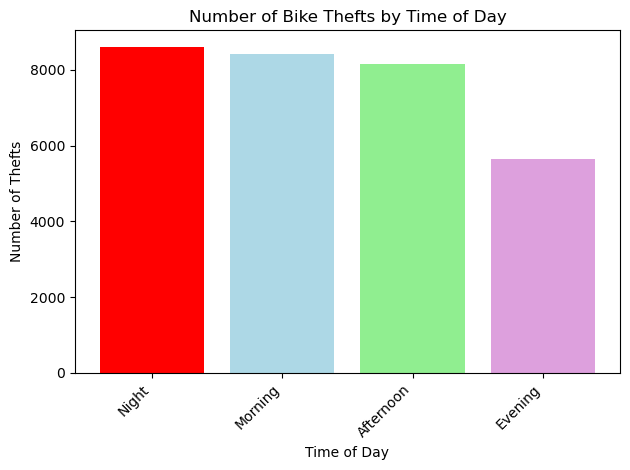

In [ ]:
#  Bar chart for bike thefts by occurence period
import matplotlib.pyplot as plt
# execute the query to get the data for plotting
c.execute('SELECT OCCURENCE_PERIOD, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = "STOLEN" GROUP BY OCCURENCE_PERIOD ORDER BY Theft_Count DESC')
result = c.fetchall()
# separate the data into two lists for plotting
periods = [row[0] for row in result]
theft_counts = [row[1] for row in result]
# define colors based on the occurrence period
colors = []
for period in periods:
    if period == "Morning":
        colors.append('lightblue')
    elif period == "Afternoon":
        colors.append('lightgreen')
    elif period == "Evening":
        colors.append('plum')
    elif period == "Night":
        colors.append('red')
# create the bar chart
plt.bar(periods, theft_counts, color=colors)
plt.xlabel('Time of Day')
plt.ylabel('Number of Thefts')
plt.title('Number of Bike Thefts by Time of Day')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# After identifying it at night, check to see which location type has the most bike thefts at night Limit this to 10 results
c.execute('SELECT LOCATION_TYPE, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = "STOLEN" AND OCCURENCE_PERIOD = "Night" GROUP BY LOCATION_TYPE ORDER BY Theft_Count DESC LIMIT 10')
result = c.fetchall()
for row in result:
    print(f"Location Type: {row[0]}, Number of Thefts: {row[1]}")

Location Type: Apartment (Rooming House, Condo), Number of Thefts: 2479
Location Type: Single Home, House (Attach Garage, Cottage, Mobile), Number of Thefts: 1865
Location Type: Streets, Roads, Highways (Bicycle Path, Private Road), Number of Thefts: 1265
Location Type: Private Property Structure (Pool, Shed, Detached Garage), Number of Thefts: 995
Location Type: Parking Lots (Apt., Commercial Or Non-Commercial), Number of Thefts: 673
Location Type: Other Commercial / Corporate Places (For Profit, Warehouse, Corp. Bldg, Number of Thefts: 394
Location Type: Bar / Restaurant, Number of Thefts: 245
Location Type: Universities / Colleges, Number of Thefts: 114
Location Type: Open Areas (Lakes, Parks, Rivers), Number of Thefts: 110
Location Type: Pharmacy, Number of Thefts: 101


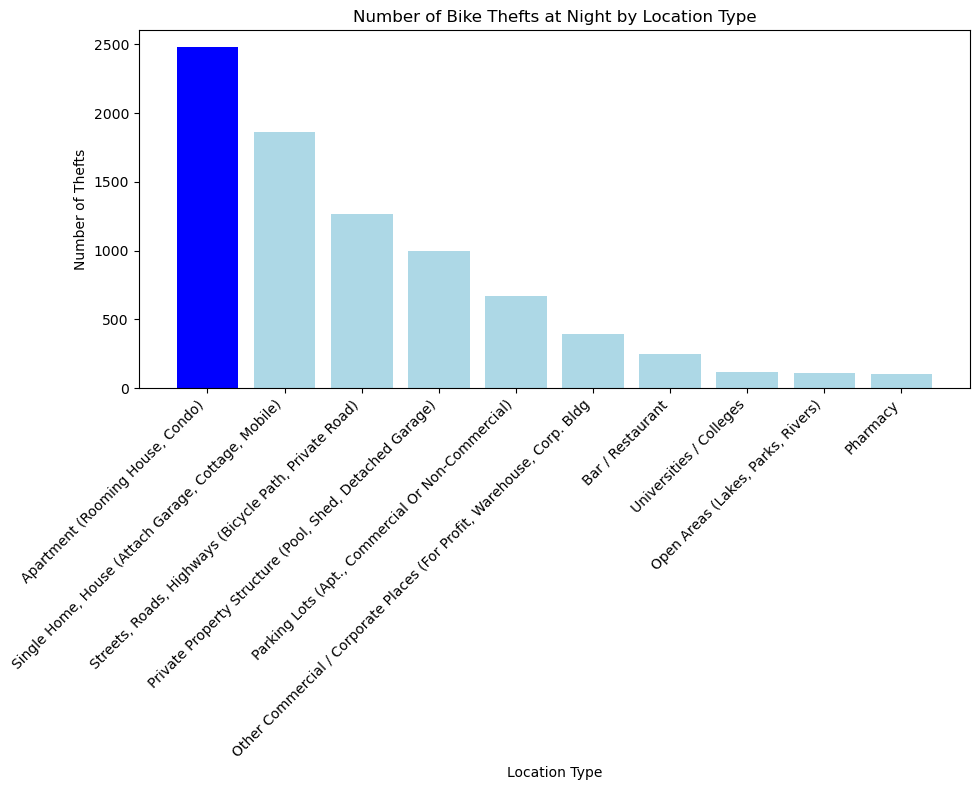

In [12]:
# Theft counts by location type at night
# Extracting the data for plotting
location_types = [row[0] for row in result]
theft_counts = [row[1] for row in result]
# Define colors for the bars
colors = ['lightblue' if location != location_types[0] else 'blue' for location in location_types]
# Create the bar chart
import matplotlib.pyplot as plt

# Set the figure size BEFORE plotting (Width, Height in inches)
# Increasing the second number (8) makes the chart taller
plt.figure(figsize=(10, 8)) 

# 2. Extracting data
location_types = [row[0] for row in result]
theft_counts = [row[1] for row in result]

# 3. Dynamic color logic: Dark blue for the maximum, light blue for others
max_thefts = max(theft_counts)
colors = ['blue' if count == max_thefts else 'lightblue' for count in theft_counts]

# 4. Create the bar chart
plt.bar(location_types, theft_counts, color=colors)

# Labels and Formatting
plt.xlabel('Location Type')
plt.ylabel('Number of Thefts')
plt.title('Number of Bike Thefts at Night by Location Type')
plt.xticks(rotation=45, ha='right')

# 5. tight_layout helps prevent labels from being cut off
plt.tight_layout()
plt.show()

In [3]:
# create a query that check the SELECT  OCCURENCE_PERIOD, LOCATION_TYPE,  (COALESCE(NEIGHBOURHOOD_158, '') || COALESCE(NEIGHBOURHOOD_140, '')) AS neighbourhood, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = 'STOLEN' AND OCCURENCE_PERIOD = 'Night' GROUP BY OCCURENCE_PERIOD,	LOCATION_TYPE, neighbourhood ORDER BY Theft_Count DESC LIMIT 15;
c.execute('SELECT OCCURENCE_PERIOD, LOCATION_TYPE,  (COALESCE(NEIGHBOURHOOD_158, "") || COALESCE(NEIGHBOURHOOD_140, "")) AS neighbourhood, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = "STOLEN" AND OCCURENCE_PERIOD = "Night" and LOCATION_TYPE = "Apartment (Rooming House, Condo)" GROUP BY OCCURENCE_PERIOD, LOCATION_TYPE, neighbourhood ORDER BY Theft_Count DESC LIMIT 15')
result = c.fetchall()
for row in result:
    print(f"Time of Day: {row[0]}, Location Type: {row[1]}, Neighbourhood: {row[2]}, Number of Thefts: {row[3]}")
    

Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: St Lawrence-East Bayfront-The Islands (166)Waterfront Communities-The Island (77), Number of Thefts: 147
Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: Wellington Place (164)Waterfront Communities-The Island (77), Number of Thefts: 140
Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: Harbourfront-CityPlace (165)Waterfront Communities-The Island (77), Number of Thefts: 135
Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: Annex (95)Annex (95), Number of Thefts: 130
Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: Fort York-Liberty Village (163)Niagara (82), Number of Thefts: 121
Time of Day: Night, Location Type: Apartment (Rooming House, Condo), Neighbourhood: Moss Park (73)Moss Park (73), Number of Thefts: 118
Time of Day: Night, Location Type: Apartment (Rooming 

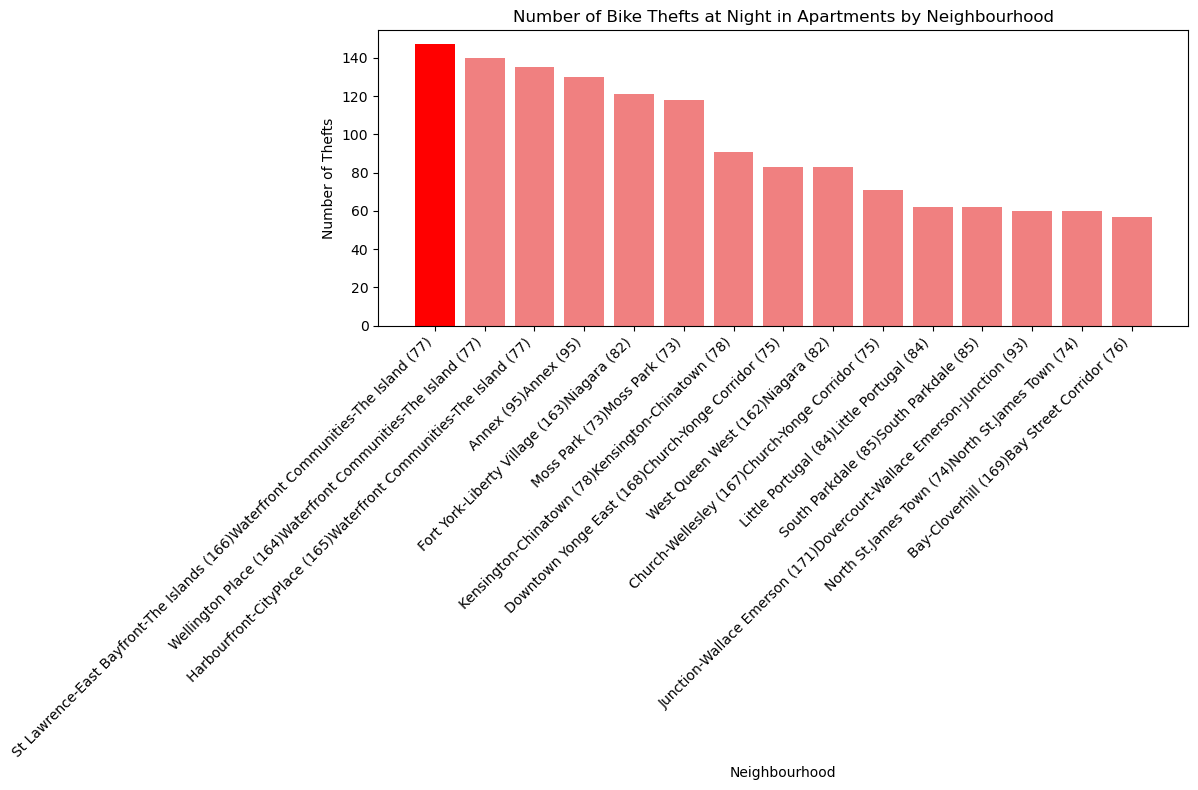

In [4]:
# Plot a bar chart of the query immediately above, use neighbourhood as the x axis and the number of thets as the y axis. I want the intersection with the highest number to be red and the rest to be light red. Make sure to rotate the x axis labels so they are readable and make the chart larger so the labels are not cut off.
import matplotlib.pyplot as plt
# Set the figure size BEFORE plotting (Width, Height in inches)
plt.figure(figsize=(12, 8))
# Extracting data for plotting
neighbourhoods = [row[2] for row in result]
theft_counts = [row[3] for row in result]
# Define colors for the bars
max_thefts = max(theft_counts)
colors = ['red' if count == max_thefts else 'lightcoral' for count in theft_counts]
# Create the bar chart
plt.bar(neighbourhoods, theft_counts, color=colors)
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Thefts')
plt.title('Number of Bike Thefts at Night in Apartments by Neighbourhood')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [11]:
import os
import folium
from IPython.display import display

# Detect latitude/longitude column names from the table schema
c.execute("PRAGMA table_info(Cleaned_Bikes)")
table_columns = {row[1].upper(): row[1] for row in c.fetchall()}

lat_col = next((table_columns[k] for k in ["LATITUDE", "LAT", "LAT_WGS84", "Y"] if k in table_columns), None)
lon_col = next((table_columns[k] for k in ["LONGITUDE", "LON", "LNG", "LONG", "LON_WGS84", "LONG_WGS84", "X"] if k in table_columns), None)

if not lat_col or not lon_col:
    raise ValueError("Could not find latitude/longitude columns in Cleaned_Bikes.")

neighbourhood_expr = '(COALESCE(NEIGHBOURHOOD_158, "") || COALESCE(NEIGHBOURHOOD_140, ""))'

# Build theft query (Night + Apartment, grouped by coordinate + neighbourhood, top 100)
c.execute(
    f'''
    SELECT
        {lat_col} AS lat,
        {lon_col} AS lon,
        {neighbourhood_expr} AS neighbourhood,
        COUNT(*) AS Theft_Count
    FROM Cleaned_Bikes
    WHERE STATUS = "STOLEN"
      AND OCCURENCE_PERIOD = "Night"
      AND LOCATION_TYPE = "Apartment (Rooming House, Condo)"
      AND {lat_col} IS NOT NULL
      AND {lon_col} IS NOT NULL
    GROUP BY lat, lon, neighbourhood
    ORDER BY Theft_Count DESC
    LIMIT 100
    '''
)

result = c.fetchall()

if not result:
    print("No matching theft records with valid coordinates were found.")
else:
    # Center the map on the average coordinate
    avg_location = [
        sum(row[0] for row in result) / len(result),
        sum(row[1] for row in result) / len(result),
    ]
    base_map = folium.Map(location=avg_location, zoom_start=12)

    # Plot red points with neighbourhood and theft count in popup
    for lat, lon, neighbourhood, theft_count in result:
        popup_text = f"Neighbourhood: {neighbourhood or 'Unknown'}, Thefts: {theft_count}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=5,
            color="red",
            fill=True,
            fill_color="red",
            fill_opacity=0.7,
            popup=popup_text,
        ).add_to(base_map)

    output_file = "bike_thefts.html"
    base_map.save(output_file)
    print(f"Map saved to: {os.path.abspath(output_file)}")

    # Show map directly in the notebook
    display(base_map)

Map saved to: c:\Users\afeen\Documents\MBAI\2026Winter- Big Data System Designs\Assignments\Afeenas Final Project\bike_thefts.html


In [15]:
# create a query to check the peak hours of the day for bike thefts 
c.execute('SELECT OCC_HOUR, COUNT(*) AS Theft_Count FROM Cleaned_Bikes WHERE STATUS = "STOLEN"  GROUP BY OCC_HOUR ORDER BY Theft_Count DESC')
result = c.fetchall()
for row in result:
    print(f"Hour: {row[0]}, Number of Thefts: {row[1]}")


Hour: 18, Number of Thefts: 2170
Hour: 17, Number of Thefts: 2023
Hour: 12, Number of Thefts: 1838
Hour: 19, Number of Thefts: 1809
Hour: 0, Number of Thefts: 1718
Hour: 9, Number of Thefts: 1683
Hour: 20, Number of Thefts: 1670
Hour: 16, Number of Thefts: 1652
Hour: 15, Number of Thefts: 1556
Hour: 14, Number of Thefts: 1485
Hour: 21, Number of Thefts: 1478
Hour: 13, Number of Thefts: 1441
Hour: 22, Number of Thefts: 1417
Hour: 23, Number of Thefts: 1378
Hour: 8, Number of Thefts: 1319
Hour: 10, Number of Thefts: 1217
Hour: 11, Number of Thefts: 1163
Hour: 1, Number of Thefts: 828
Hour: 7, Number of Thefts: 688
Hour: 2, Number of Thefts: 564
Hour: 6, Number of Thefts: 503
Hour: 3, Number of Thefts: 486
Hour: 5, Number of Thefts: 373
Hour: 4, Number of Thefts: 371


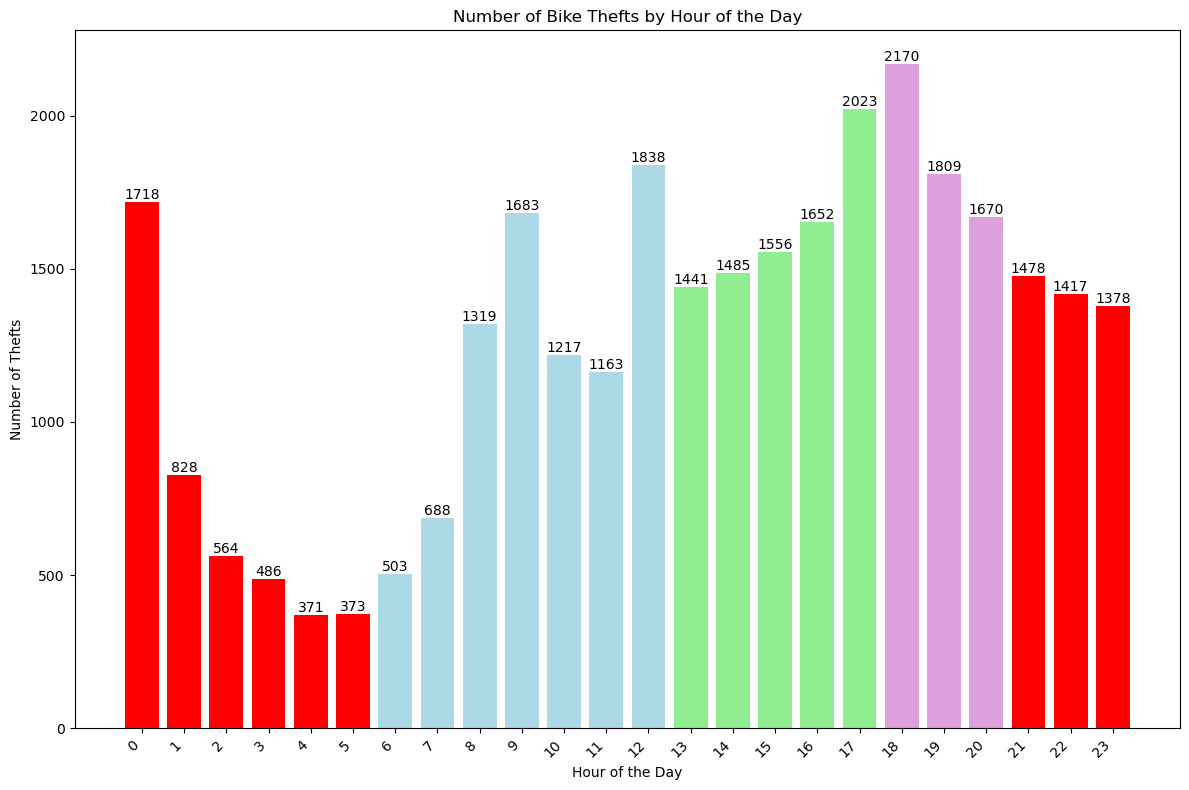

In [16]:
# Bike theft by hour using above query
import matplotlib.pyplot as plt
# Set the figure size BEFORE plotting (Width, Height in inches)
plt.figure(figsize=(12, 8))
# Extracting data for plotting
hours = [row[0] for row in result]
theft_counts = [row[1] for row in result]  
# Define colors based on the specified time ranges
colors = []
for hour in hours:
    if 6 <= hour <= 12:
        colors.append('lightblue')
    elif 12 < hour <= 17:
        colors.append('lightgreen')
    elif 17 < hour <= 20:
        colors.append('plum')
    else:
        colors.append('red')
# Create the bar chart
    plt.bar(hours, theft_counts, color=colors)
# Add counts on top of the bars
for i, count in enumerate(theft_counts):
    plt.text(hours[i], count, str(count), ha='center', va='bottom')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Thefts')
plt.title('Number of Bike Thefts by Hour of the Day')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# add all values on the x-axis
plt.xticks(hours)
plt.show()


In [13]:
# Quick summary metrics for insights
neighbourhood_expr = '(COALESCE(NEIGHBOURHOOD_158, "") || COALESCE(NEIGHBOURHOOD_140, ""))'

# Top 5 neighbourhoods for apartment thefts at night
c.execute(
    f'''
    SELECT {neighbourhood_expr} AS neighbourhood, COUNT(*) AS theft_count
    FROM Cleaned_Bikes
    WHERE STATUS = "STOLEN"
      AND OCCURENCE_PERIOD = "Night"
      AND LOCATION_TYPE = "Apartment (Rooming House, Condo)"
    GROUP BY neighbourhood
    ORDER BY theft_count DESC
    LIMIT 5
    '''
)
top5 = c.fetchall()

# Total apartment-night theft incidents
c.execute(
    '''
    SELECT COUNT(*)
    FROM Cleaned_Bikes
    WHERE STATUS = "STOLEN"
      AND OCCURENCE_PERIOD = "Night"
      AND LOCATION_TYPE = "Apartment (Rooming House, Condo)"
    '''
)
total_apartment_night = c.fetchone()[0]

# Distinct coordinate points used for mapping
c.execute("PRAGMA table_info(Cleaned_Bikes)")
table_columns = {row[1].upper(): row[1] for row in c.fetchall()}
lat_col = next((table_columns[k] for k in ["LATITUDE", "LAT", "LAT_WGS84", "Y"] if k in table_columns), None)
lon_col = next((table_columns[k] for k in ["LONGITUDE", "LON", "LNG", "LONG", "LON_WGS84", "LONG_WGS84", "X"] if k in table_columns), None)

if lat_col and lon_col:
    c.execute(
        f'''
        SELECT COUNT(*)
        FROM (
            SELECT {lat_col}, {lon_col}, {neighbourhood_expr}
            FROM Cleaned_Bikes
            WHERE STATUS = "STOLEN"
              AND OCCURENCE_PERIOD = "Night"
              AND LOCATION_TYPE = "Apartment (Rooming House, Condo)"
              AND {lat_col} IS NOT NULL
              AND {lon_col} IS NOT NULL
            GROUP BY {lat_col}, {lon_col}, {neighbourhood_expr}
        )
        '''
)
    mapped_points = c.fetchone()[0]
else:
    mapped_points = None

print(f"Total apartment-night theft incidents: {total_apartment_night}")
print(f"Distinct map points available: {mapped_points}")
print("Top 5 neighbourhoods by apartment-night theft count:")
for name, cnt in top5:
    print(f"- {name or 'Unknown'}: {cnt}")

Total apartment-night theft incidents: 2479
Distinct map points available: 1062
Top 5 neighbourhoods by apartment-night theft count:
- St Lawrence-East Bayfront-The Islands (166)Waterfront Communities-The Island (77): 147
- Wellington Place (164)Waterfront Communities-The Island (77): 140
- Harbourfront-CityPlace (165)Waterfront Communities-The Island (77): 135
- Annex (95)Annex (95): 130
- Fort York-Liberty Village (163)Niagara (82): 121
